# **Fase 5b: Diagnóstico Geométrico y Optimización Conjunta (Grid Search)**

**Autor:** Andoni Cabrera Fernández

**Descripción Técnica:**
Este cuaderno actúa como el motor de inferencia geométrica del sistema. Carga la telemetría topológica tridimensional (EAR y MAR) previamente serializada en formato comprimido y ejecuta la lógica clínica preventiva descrita en la memoria:

1. **Calibración Biométrica Asíncrona:** Se implementa un período de *Warm-up* dinámico para extraer la media ($\mu$) y la desviación estándar ($\sigma$) del EAR basal del conductor al iniciar la marcha. Esto permite establecer un umbral de oclusión palpebral personalizado, acotado siempre por un límite duro de seguridad ($EAR_{th} \ge 0.18$) para evitar sesgos.
2. **Diagnóstico Predictivo Multiclase:** Mapeo a los estados de prevención de la escala KSS (Clases 0, 5 y 10), priorizando el cálculo continuo del estándar PERCLOS para la somnolencia crítica y el filtro de racha de bostezos para la baja vigilancia.

Finalmente, se ejecuta un algoritmo de **Búsqueda en Malla (*Grid Search 4D*)** exhaustivo. El objetivo es aislar la combinación matemática óptima cruzando variables clave: la frecuencia de muestreo temporal (evaluando a **30, 15, 5 y 1 FPS**), las ventanas de integración del PERCLOS, la sensibilidad palpebral y los tiempos de bostezo, buscando maximizar el *F1-Score* clínico sobre conductores no vistos.

**1. IMPORTACIÓN E INFRAESTRUCTURA**

In [2]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y ENTORNO
# ==============================================================================
from google.colab import drive
import os
import pandas as pd
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Montaje del sistema de archivos distribuido
drive.mount('/content/drive')

# Definición del espacio de trabajo persistente
RUTA_BASE = '/content/drive/MyDrive/TFG_Fatiga_Colab/PKL_GEOMETRIA/'

if not os.path.exists(RUTA_BASE):
    print(f"Ruta no encontrada: {RUTA_BASE}. Verifica el montaje de Drive.")
else:
    print("Entorno cargado correctamente.")

Mounted at /content/drive
Entorno cargado correctamente.


**2. MOTOR DE INFERENCIA GEOMÉTRICA (LATE FUSION)**

In [3]:
# ==============================================================================
# 2. DEFINICIÓN DEL MOTOR DE INFERENCIA CLÍNICA
# ==============================================================================
def evaluar_videos_geometricos(df, fps, warmup_sec, perclos_th, mar_th, bostezo_sec_th, sigma_mult, ear_min):
    """
    Motor central que procesa la telemetría aplicando Warm-Up biométrico y evalúa
    el estado del conductor basándose en los estándares PERCLOS y MAR crudos.
    """
    resultados = []

    for video_name, grupo in df.groupby('video'):
        total_frames = len(grupo)
        if total_frames == 0:
            continue

        clase_real = grupo['clase_real'].iloc[0]

        # 1. Calibración biométrica asíncrona (Warm-Up)
        frames_warmup = int(warmup_sec * fps)
        if frames_warmup == 0 or frames_warmup > total_frames:
            frames_warmup = min(20 * fps, total_frames)

        ear_calibracion = grupo['ear'].iloc[:frames_warmup]
        mu_ear = ear_calibracion.mean()
        sigma_ear = ear_calibracion.std()

        # Umbral EAR dinámico acotado por límite físico
        umbral_ear_dinamico = max(mu_ear - (sigma_mult * sigma_ear), ear_min)

        # 2. Extracción de firmas temporales
        # Cierre Ocular (Somnolencia extrema)
        es_cerrado = grupo['ear'] < umbral_ear_dinamico
        perclos = es_cerrado.sum() / total_frames

        # Bostezo (Baja vigilancia)
        es_bostezo = grupo['mar'] > mar_th
        rachas = es_bostezo.groupby((~es_bostezo).cumsum()).sum()
        max_frames_bostezo = rachas.max() if not rachas.empty else 0
        segundos_max_bostezo = max_frames_bostezo / fps

        # 3. Árbol de decisión
        if perclos >= perclos_th:
            clase_predicha = 10
        elif segundos_max_bostezo >= bostezo_sec_th:
            clase_predicha = 5
        else:
            clase_predicha = 0

        resultados.append({
            'video': video_name,
            'real': clase_real,
            'pred': clase_predicha
        })

    return pd.DataFrame(resultados)

**3. ANÁLISIS DE TELEMETRÍA Y CONTROL DE CALIDAD (Baseline 5 FPS)**

In [4]:
# ==============================================================================
# 3. CARGA DE EVIDENCIA Y ANÁLISIS ESTADÍSTICO (Baseline 5 FPS)
# ==============================================================================
print("Cargando bases de datos geométricas desde la memoria local...")

with open(f'{RUTA_BASE}geometria_1fps.pkl', 'rb') as f:
    df_1 = pd.DataFrame(pickle.load(f))
with open(f'{RUTA_BASE}geometria_5fps.pkl', 'rb') as f:
    df_5 = pd.DataFrame(pickle.load(f))
with open(f'{RUTA_BASE}geometria_15fps.pkl', 'rb') as f:
    df_15 = pd.DataFrame(pickle.load(f))
with open(f'{RUTA_BASE}geometria_30fps.pkl', 'rb') as f:
    df_30 = pd.DataFrame(pickle.load(f))

print(f"Archivos cargados. Registros: 1FPS ({len(df_1)}), 5FPS ({len(df_5)}), 15FPS ({len(df_15)}), 30FPS ({len(df_30)})\n")

print("--- 1. RESUMEN ESTADÍSTICO DE LAS PREDICCIONES (5 FPS) ---\n")
print(df_5[['ear', 'mar']].describe())

print("\n--- 2. ¿HAY VALORES NULOS O VACÍOS? ---\n")
print(df_5.isnull().sum())

print("\n--- 3. MUESTRA DE LAS PRIMERAS 10 INFERENCIAS ---\n")
print(df_5[['video', 'frame_idx', 'ear', 'mar', 'clase_real']].head(10))

Cargando bases de datos geométricas desde la memoria local...
Archivos cargados. Registros: 1FPS (101108), 5FPS (505607), 15FPS (1516651), 30FPS (3033233)

--- 1. RESUMEN ESTADÍSTICO DE LAS PREDICCIONES (5 FPS) ---

                 ear            mar
count  505607.000000  505607.000000
mean        0.263183       0.025864
std         0.057628       0.052624
min         0.011866       0.000103
25%         0.240963       0.009425
50%         0.271271       0.015690
75%         0.298740       0.025959
max         0.534408       1.600470

--- 2. ¿HAY VALORES NULOS O VACÍOS? ---

video         0
clase_real    0
frame_idx     0
ear           0
mar           0
dtype: int64

--- 3. MUESTRA DE LAS PRIMERAS 10 INFERENCIAS ---

      video  frame_idx       ear       mar  clase_real
0  01_0.mov          0  0.245535  0.022611           0
1  01_0.mov          6  0.275812  0.024096           0
2  01_0.mov         12  0.259315  0.022283           0
3  01_0.mov         18  0.256804  0.027210           

**4. GRID SEARCH DUAL (Optimización de Hiperparámetros)**

In [5]:
# ==============================================================================
# 4. DEFINICIÓN DEL ESPACIO DE BÚSQUEDA Y OPTIMIZACIÓN MULTICRITERIO
# ==============================================================================
espacio_warmup = [40]
espacio_perclos = [0.05, 0.06, 0.07, 0.08]
espacio_mar = [0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24]
espacio_bostezo_sec = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
espacio_sigma_mult = [2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1]
espacio_ear_min = [0.17, 0.18, 0.19, 0.20]

datasets = {
    '1 FPS': (df_1, 1),
    '5 FPS': (df_5, 5),
    '15 FPS': (df_15, 15),
    '30 FPS': (df_30, 30)
}

mejores_modelos_f1 = {}
mejores_modelos_acc = {}

total_combs = (len(espacio_warmup) * len(espacio_perclos) * len(espacio_mar) * len(espacio_bostezo_sec) * len(espacio_sigma_mult) * len(espacio_ear_min))

print(f"Iniciando búsqueda dual ({total_combs} combinaciones por FPS)...")

for nombre_fps, (df_data, fps_val) in datasets.items():
    inicio_tiempo = time.time()
    resultados_grid = []

    for w_sec in espacio_warmup:
        for p_th in espacio_perclos:
            for m_th in espacio_mar:
                for b_sec in espacio_bostezo_sec:
                    for s_mult in espacio_sigma_mult:
                        for e_min in espacio_ear_min:
                            res_df = evaluar_videos_geometricos(
                                df_data, fps=fps_val, warmup_sec=w_sec,
                                perclos_th=p_th, mar_th=m_th, bostezo_sec_th=b_sec,
                                sigma_mult=s_mult, ear_min=e_min
                            )

                            acc = accuracy_score(res_df['real'], res_df['pred'])
                            f1 = f1_score(res_df['real'], res_df['pred'], average='macro', zero_division=0)

                            resultados_grid.append({
                                'WarmUp': w_sec, 'PERCLOS': p_th, 'MAR': m_th,
                                'Bostezo': b_sec, 'Sigma': s_mult, 'EAR_Min': e_min,
                                'Accuracy': acc, 'F1_Score': f1
                            })

    tiempo_procesamiento = time.time() - inicio_tiempo
    df_resultados_fps = pd.DataFrame(resultados_grid)

    # 1. Extraer el mejor por F1-Score (prioriza evitar falsos negativos)
    df_top_f1 = df_resultados_fps.sort_values(by=['F1_Score', 'Accuracy'], ascending=[False, False]).head(1)
    mejores_modelos_f1[nombre_fps] = {
        'Top_Config': df_top_f1.iloc[0],
        'Tiempo_Busqueda': tiempo_procesamiento
    }

    # 2. Extraer el mejor por Accuracy (prioriza evitar falsas alarmas)
    df_top_acc = df_resultados_fps.sort_values(by=['Accuracy', 'F1_Score'], ascending=[False, False]).head(1)
    mejores_modelos_acc[nombre_fps] = {
        'Top_Config': df_top_acc.iloc[0]
    }

print("Búsqueda en cuadrícula finalizada.")

Iniciando búsqueda dual (7168 combinaciones por FPS)...
Búsqueda en cuadrícula finalizada.


**5. REPORTE COMPARATIVO Y EVALUACIÓN MULTI-FPS**

In [6]:
# ==============================================================================
# 5. REPORTE DE RENDIMIENTO (F1 vs ACCURACY)
# ==============================================================================
print("="*85)
print("RESULTADOS PRIORIZANDO F1-SCORE (Evitar Falsos Negativos)")
print("="*85)
for fps, datos in mejores_modelos_f1.items():
    top = datos['Top_Config']
    print(f"[{fps}] F1: {top['F1_Score']*100:.2f}% | Acc: {top['Accuracy']*100:.2f}% --> "
          f"WarmUp: {top['WarmUp']}s | P: {top['PERCLOS']} | M: {top['MAR']} | "
          f"B: {top['Bostezo']}s | Sig: {top['Sigma']}x | EAR: {top['EAR_Min']}")

print("\n" + "="*85)
print("RESULTADOS PRIORIZANDO ACCURACY (Evitar Falsas Alarmas)")
print("="*85)
for fps, datos in mejores_modelos_acc.items():
    top = datos['Top_Config']
    print(f"[{fps}] Acc: {top['Accuracy']*100:.2f}% | F1: {top['F1_Score']*100:.2f}% --> "
          f"WarmUp: {top['WarmUp']}s | P: {top['PERCLOS']} | M: {top['MAR']} | "
          f"B: {top['Bostezo']}s | Sig: {top['Sigma']}x | EAR: {top['EAR_Min']}")
print("="*85)

RESULTADOS PRIORIZANDO F1-SCORE (Evitar Falsos Negativos)
[1 FPS] F1: 30.71% | Acc: 51.67% --> WarmUp: 40.0s | P: 0.07 | M: 0.18 | B: 0.1s | Sig: 2.6x | EAR: 0.19
[5 FPS] F1: 31.03% | Acc: 54.44% --> WarmUp: 40.0s | P: 0.06 | M: 0.22 | B: 0.5s | Sig: 3.0x | EAR: 0.18
[15 FPS] F1: 31.45% | Acc: 56.67% --> WarmUp: 40.0s | P: 0.06 | M: 0.23 | B: 0.8s | Sig: 3.0x | EAR: 0.18
[30 FPS] F1: 31.54% | Acc: 55.56% --> WarmUp: 40.0s | P: 0.07 | M: 0.22 | B: 0.5s | Sig: 2.6x | EAR: 0.19

RESULTADOS PRIORIZANDO ACCURACY (Evitar Falsas Alarmas)
[1 FPS] Acc: 53.33% | F1: 30.53% --> WarmUp: 40.0s | P: 0.07 | M: 0.24 | B: 0.1s | Sig: 2.6x | EAR: 0.19
[5 FPS] Acc: 55.00% | F1: 30.73% --> WarmUp: 40.0s | P: 0.06 | M: 0.23 | B: 0.7s | Sig: 3.0x | EAR: 0.18
[15 FPS] Acc: 56.67% | F1: 31.45% --> WarmUp: 40.0s | P: 0.06 | M: 0.23 | B: 0.8s | Sig: 3.0x | EAR: 0.18
[30 FPS] Acc: 56.11% | F1: 31.25% --> WarmUp: 40.0s | P: 0.07 | M: 0.22 | B: 0.7s | Sig: 2.6x | EAR: 0.19


**6. MATRIZ DE CONFUSIÓN FINAL (RENDIMIENTO ÓPTIMO)**

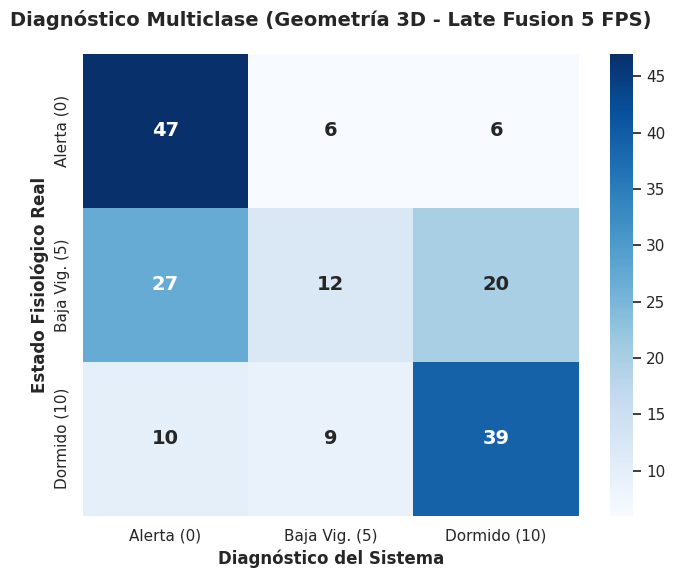


REPORTE CLÍNICO FINAL DE CLASIFICACIÓN (5 FPS)
               precision    recall  f1-score   support

   Alerta (0)       0.55      0.80      0.65        59
Baja Vig. (5)       0.44      0.20      0.28        59
 Dormido (10)       0.58      0.67      0.62        58

    micro avg       0.54      0.56      0.55       176
    macro avg       0.52      0.56      0.52       176
 weighted avg       0.52      0.56      0.52       176



In [7]:
# ==============================================================================
# 6. RENDERIZADO DEL DIAGNÓSTICO DEFINITIVO (ESTÁNDAR 5 FPS)
# ==============================================================================
# Extraemos la mejor configuración a 5 FPS (Priorizando F1-Score)
top_5fps = mejores_modelos_f1['5 FPS']['Top_Config']

# Ejecutamos el motor geométrico con los hiperparámetros ganadores
df_optimo = evaluar_videos_geometricos(
    df_5,
    fps=5,
    warmup_sec=top_5fps['WarmUp'],
    perclos_th=top_5fps['PERCLOS'],
    mar_th=top_5fps['MAR'],
    bostezo_sec_th=top_5fps['Bostezo'],
    sigma_mult=top_5fps['Sigma'],
    ear_min=top_5fps['EAR_Min']
)

y_true = df_optimo['real']
y_pred = df_optimo['pred']

# Renderizado de la matriz de confusión
matriz_conf = confusion_matrix(y_true, y_pred, labels=[0, 5, 10])
etiquetas_clinicas = ['Alerta (0)', 'Baja Vig. (5)', 'Dormido (10)']

plt.figure(figsize=(8, 6))
sns.set_theme(style="white")
sns.heatmap(
    matriz_conf, annot=True, fmt='d', cmap='Blues',
    xticklabels=etiquetas_clinicas, yticklabels=etiquetas_clinicas,
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Diagnóstico Multiclase (Geometría 3D - Late Fusion 5 FPS)', pad=20, fontsize=14, fontweight='bold')
plt.ylabel('Estado Fisiológico Real', fontsize=12, fontweight='bold')
plt.xlabel('Diagnóstico del Sistema', fontsize=12, fontweight='bold')
plt.show()

# Reporte formal de métricas
print("\n" + "="*55)
print("REPORTE CLÍNICO FINAL DE CLASIFICACIÓN (5 FPS)")
print("="*55)
print(classification_report(y_true, y_pred, labels=[0, 5, 10], target_names=etiquetas_clinicas))